# Figure 2: Model-based quantification of intra-session dynamics of inter-run duration.

## setup and imports

In [95]:
import fnmatch
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from matplotlib.offsetbox import DrawingArea, HPacker, VPacker, AnchoredOffsetbox, TextArea
import numpy as np
import glob
from scipy.ndimage import gaussian_filter as smooth

from sessionlists import (dist60, dist90, dist120, TM20, TM10, TM2, TMrev2, TMrev10, TMrev20)
from utils import *
from plotting import *
from model_functions import *

plt.style.use('./Figures/paper.mplstyle')

In [96]:
# Define folder with data
root = "/home/thomas/Desktop/ALLDATA"

print("Path to data is: %s"%root)
print(f'Found {len(glob.glob(root+"/*"))} rats in the data folder')

Path to data is: /home/thomas/Desktop/ALLDATA
Found 34 rats in the data folder


In [97]:
rat_markers = {}
sequence = {}

# INTACT RATS
animalList = ['RatF00', 'RatF01', 'RatF02', 'RatM00', 'RatM01', 'RatM02', 
            'RatF32', 'RatF33', 'RatM31', 'RatM32', 'RatF42', 'RatM40', 'RatM43', 'RatM53', 'RatM54']

m, f = 0, 0
male_palette = create_teal_palette(num_shades=len([x for x in animalList if 'M' in x]))
female_palette = create_blue_violet_palette(num_shades=len([x for x in animalList if 'F' in x]), start_intensity=80)

for index, animal in enumerate(animalList):
    print(f'Loading data for {animal}')
    # define marker and color for each rat, used in plots
    if fnmatch.fnmatch(animal, 'RatF*'):
        rat_markers[animal]=[female_palette[f], 'o', '-']
        f += 1
    elif fnmatch.fnmatch(animal, 'RatM*'):
        rat_markers[animal]=[male_palette[m], 'o', '-']
        m += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")
        
    for session in sorted(matchsession(animal, dist60+dist90+dist120 + TM20+TM10+TM2+TMrev2+TMrev10+TMrev20)):
        sequence[animal, session] = get_from_pickle(root, animal[0:6], session, name="sequence.p")

 

Loading data for RatF00
Loading data for RatF01
Loading data for RatF02
Loading data for RatM00
Loading data for RatM01
Loading data for RatM02
Loading data for RatF32
Loading data for RatF33
Loading data for RatM31
Loading data for RatM32
Loading data for RatF42
Loading data for RatM40
Loading data for RatM43
Loading data for RatM53
Loading data for RatM54


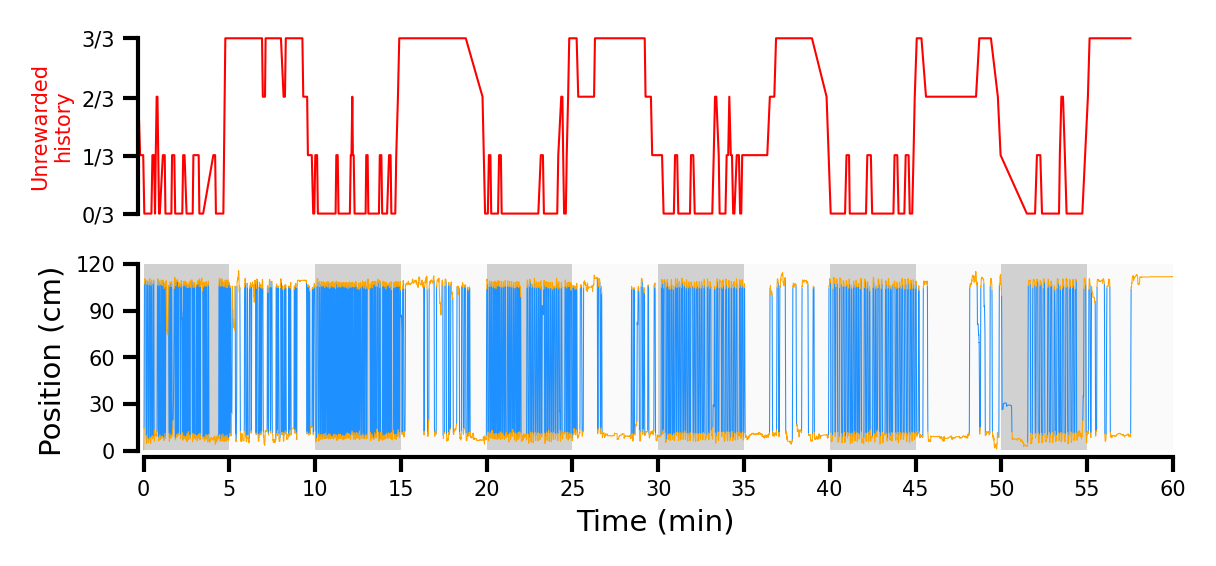

In [98]:

def Figure1B(root, 
            animal='RatM00', session='RatM00_2021_07_22_16_13_03', 
            ax=None):
    '''
    read position file and plot animal trajectory
    '''
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize = (cm2inch(10), cm2inch(4.5)))

    params = get_from_pickle(root, animal, session, name="params.p")
    time = read_csv_pandas((root+os.sep+animal+os.sep+"Experiments"+os.sep + session + os.sep+session+".position"), Col=[3])[:90000]
    pos  = read_csv_pandas((root+os.sep+animal+os.sep+"Experiments"+os.sep + session + os.sep+session+".position"), Col=[4])[:90000]/11
    mask = stitch([get_from_pickle(root, animal, session, name="mask.p")])[0]   
    pos = smooth(pos.astype('float32'), 2)

    running_Xs = [val[0] if val[1] == True else None for val in [[i, j] for i, j in zip(pos, mask)]]
    idle_Xs = [val[0] if val[1] == False else None for val in [[i, j] for i, j in zip(pos, mask)]]

    for i in range(0, len(params['blocks'])):
        ax.axvspan(params['blocks'][i][0], params['blocks'][i][1], ymin=1/30, ymax=1,
                    color='grey', alpha=params['rewardProbaBlock'][i]/250, linewidth=0)

    ax.plot(time, running_Xs, color="dodgerblue", lw=.25)
    ax.plot(time, idle_Xs, color="orange", lw=.25)

    ax.set_xlim(0, 3600)
    ax.set_ylim(0, 120)
    ax.set_xticks(np.arange(0, 3601, 300))
    ax.set_xticklabels(np.arange(0, 61, 5))
    ax.set_yticks(np.arange(0, 121, 30))
    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Position (cm)")
    space_axes(ax, x_ratio_right=0, x_ratio_left=1/180)


def Figure1Bbis(root, 
            animal='RatM00', session='RatM00_2021_07_22_16_13_03', 
            ax=None):

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(10, 5))

    params = get_from_pickle(root, animal, session, name="params.p")
    seq = get_from_pickle(root, animal, session, name="sequence.p")

    time = np.arange(0, 3600, 1)
    rewardProba = np.ones(3600)

    for t in range(0, len(time)):
        for i in range(0, len(params['blocks'])):
            if time[t] in range(params['blocks'][i][0], params['blocks'][i][1]):
                rewardProba[t] *= params['rewardProbaBlock'][i]

    time_of_reward = []
    received_reward = []
    for elem in seq:
        if seq[elem][1] == 'run':
            time_of_reward.append(seq[elem][0])
            received_reward.append(seq[elem][2])

    ax.set_xlim(0, 3600)
    ax.set_ylim(-0.05, 1.05)
    ax.set_yticks([0, 0.33, 0.66, 1])
    ax.set_yticklabels(["0/3", "1/3", "2/3", "3/3"], fontsize=5)
    ax.set_ylabel('Unrewarded\nhistory', color='r', fontsize=5)
    ax.plot(time_of_reward, abs(1 - movinavg(received_reward, 3)), 'r', lw=.5)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
    ax.spines['left'].set_bounds(0, 1)



fig, axs = plt.subplots(2, 1, figsize = (cm2inch(10), cm2inch(4.5)))
Figure1B(ax=axs[1], root=root)
Figure1Bbis(ax=axs[0], root=root)

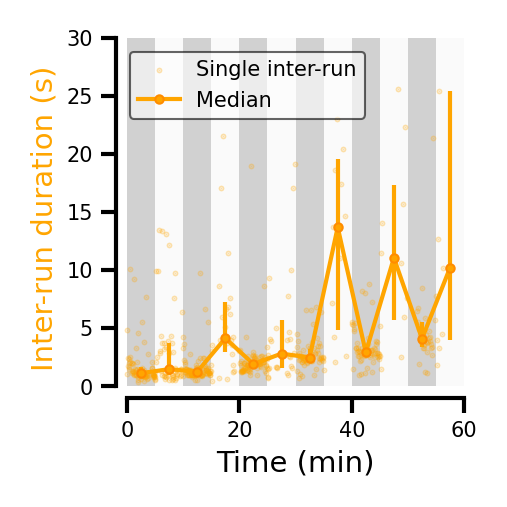

In [99]:

def Figure1D(root, 
             animal='RatM00', session='RatM00_2021_07_22_16_13_03', 
             
             ax=None):
    
    warnings.simplefilter("ignore", category=RuntimeWarning)
    if ax is None:
        ax = plt.gca()

    params = get_from_pickle(root, animal, session, name="params.p")
    blocks = params['blocks']
    rewardProbaBlock = params['rewardProbaBlock']
    example_idleTimeInLeftBin, example_idleTimeInRightBin = get_from_pickle(root, animal, session, name="timeinZone.p")
    data = [example_idleTimeInLeftBin[i]+example_idleTimeInRightBin[i] for i in range(0, 12)]

    for i in range(0, len(blocks)):
        ax.axvspan(blocks[i][0]/60, blocks[i][1]/60, ymin=1/30, ymax=1, color='grey', alpha=rewardProbaBlock[i]/250, lw=0)

    data_medians = [np.median(data[i]) for i in range(12)]
    data_bot_percentiles = [np.percentile(data[i], 25) for i in range(12)]
    data_top_percentiles = [np.percentile(data[i], 75) for i in range(12)]
        
    ax.errorbar([(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                data_medians,
                yerr=[[data_medians[i]-data_bot_percentiles[i] for i in range(12)], [data_top_percentiles[i]-data_medians[i] for i in range(12)]],
                marker='o', ms=2, color='orange', ecolor='orange',
                zorder=4, markeredgecolor='darkorange', markeredgewidth=0.5, alpha=1)

    ax.plot([-100, -101], [-100, -101], marker='o', ms=2, color='orange',
                zorder=4, markeredgecolor='darkorange', markeredgewidth=0.5, alpha=1, label='Median')

    ax.set_xlabel("Time (min)")
    ax.set_ylabel("Inter-run duration (s)", color='orange')
    ax.set_xlim(0, 60)
    ax.set_ylim(0, 30)

    _x, _y = [], []
    sequence = get_from_pickle(root, animal, session, name="sequence.p")
    for elem in sequence: 
        if sequence[elem][1]=='stay':
            _x.append(sequence[elem][0]/60)
            _y.append(sequence[elem][3])

    ax.scatter(_x, _y, marker='o', s=.15, color='orange', zorder=3, label='Single inter-run', alpha=0.33)


    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique[::-1]), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)
    space_axes(ax)


fig, ax = plt.subplots(1, 1, figsize = (cm2inch(4), cm2inch(4)))
Figure1D(ax=ax, root=root)

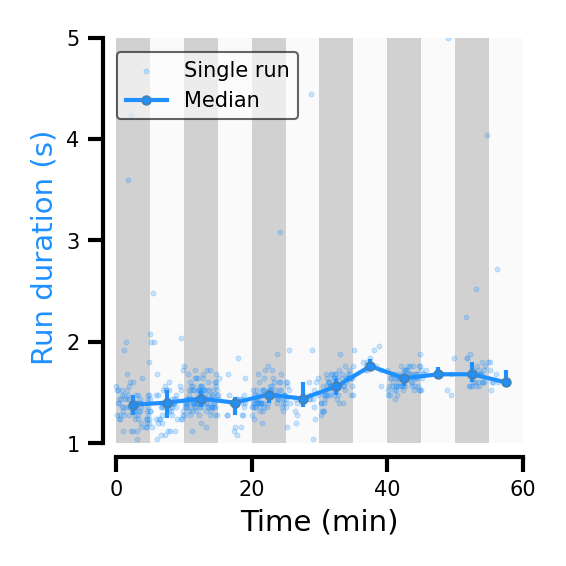

In [100]:
def Figure1E(root, 
             animal='RatM00', session='RatM00_2021_07_22_16_13_03', 
             ax=None):
    
    warnings.simplefilter("ignore", category=RuntimeWarning)
    if ax is None:
        ax = plt.gca()

    params = get_from_pickle(root, animal, session, name="params.p")
    blocks = params['blocks']
    rewardProbaBlock = params['rewardProbaBlock']
    example_runningTimeInLeftBin, example_runningTimeInRightBin = get_from_pickle(root, animal, session, name="timeRun.p")
    data = [example_runningTimeInLeftBin[i]+example_runningTimeInRightBin[i] for i in range(0, 12)]

    for i in range(0, len(blocks)):
        ax.axvspan(blocks[i][0]/60, blocks[i][1]/60, ymin=1/30, ymax=1, color='grey', alpha=rewardProbaBlock[i]/250, lw=0)

    data_medians = [np.median(data[i]) for i in range(12)]
    data_bot_percentiles = [np.percentile(data[i], 25) for i in range(12)]
    data_top_percentiles = [np.percentile(data[i], 75) for i in range(12)]
        
    ax.errorbar([(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                data_medians,
                yerr=[[data_medians[i]-data_bot_percentiles[i] for i in range(12)], [data_top_percentiles[i]-data_medians[i] for i in range(12)]],
                marker='o', ms=2, color='dodgerblue', ecolor='dodgerblue',
                zorder=4, markeredgecolor='steelblue', markeredgewidth=0.5, alpha=1)

    ax.plot([-100, -101], [-100, -101], marker='o', ms=2, color='dodgerblue',
                zorder=4, markeredgecolor='steelblue', markeredgewidth=0.5, alpha=1, label='Median')

    ax.set_xlim(0, 60)
    ax.set_xlabel("Time (min)")

    ax.set_ylim(1, 5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_ylabel("Run duration (s)", color='dodgerblue')


    _x, _y = [], []
    sequence = get_from_pickle(root, animal, session, name="sequence.p")
    for elem in sequence: 
        if sequence[elem][1]=='run':
            _x.append(sequence[elem][0]/60)
            _y.append(sequence[elem][3])

    ax.scatter(_x, _y, marker='o', s=.15, color='dodgerblue', zorder=3, label='Single run', alpha=0.33)


    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique[::-1]), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)
    space_axes(ax)

fig, ax = plt.subplots(1, 1, figsize = (cm2inch(4.5), cm2inch(4.5)))
Figure1E(ax=ax, root=root)

# 2ABC right simulated distribution

In [101]:

def custom_combined_legend(ax, val1, val2, letter1, letter2, color1, color2, timebin=0, historybin=0, bbox=(.05, 1.0)):
    framealpha = 0.6
    facecolor = 'white'
    edgecolor = 'k'
    fontsize = 5

    borderpad = 0.2
    labelspacing = 0.
    handlelength = 4
    handleheight = 1
    handletextpad = 1

    ########
    line1 = Line2D([0, handlelength], [0, 0], color='gray', lw=1)
    txt1 = TextArea(f"Example session\n({timebin*10}-{(timebin+1)*10} min, u={historybin}/3)", textprops=dict(color='black', fontsize=fontsize))
    entry1 = HPacker(children=[TextArea(""), txt1], align="baseline", pad=0, sep=handletextpad)

    da1 = DrawingArea(handlelength, handleheight, 0, 0)
    da1.add_artist(line1)

    #######""
    line2 = Line2D([0, handlelength], [0, 0], color='k', lw=1)
    txt2a = TextArea("Fitted distribution", textprops=dict(color='black', fontsize=fontsize))
    txt_alpha = TextArea(letter1, textprops=dict(color=color1, fontsize=fontsize))
    txt_eq_a = TextArea(f"={val1:.2f}, ", textprops=dict(color='black', fontsize=fontsize))
    txt_gamma = TextArea(letter2, textprops=dict(color=color2, fontsize=fontsize))
    txt_eq_g = TextArea(f"={val2:.2f}", textprops=dict(color='black', fontsize=fontsize))
    param_line = HPacker(children=[txt_alpha, txt_eq_a, txt_gamma, txt_eq_g], align="baseline", pad=0, sep=1)

    txt2 = VPacker(children=[txt2a, param_line], align="left", pad=0, sep=labelspacing)
    entry2 = HPacker(children=[TextArea(""), txt2], align="baseline", pad=0, sep=handletextpad)

    da2 = DrawingArea(handlelength, handleheight, 0, 0)
    da2.add_artist(line2)

    packed = VPacker(children=[
        HPacker(children=[da1, entry1], align="center", pad=0, sep=handletextpad),
        HPacker(children=[da2, entry2], align="center", pad=0, sep=handletextpad)
    ], align="left", pad=0, sep=labelspacing)

    box = AnchoredOffsetbox(loc='upper left', bbox_to_anchor=bbox,
                            bbox_transform=ax.transAxes,
                            child=packed, frameon=True, pad=borderpad, borderpad=borderpad)
    box.patch = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle=f"round,pad={borderpad},rounding_size=.2",
        ec=edgecolor, fc=facecolor, lw=0.5,
        alpha=framealpha,
        mutation_aspect=1
    )

    ax.add_artist(box)

def equation_legend(ax, equation, names, values, color='k', bbox=(0.5, 1.02)):
    framealpha = 0.6
    facecolor = 'white'
    edgecolor = 'k'

    borderpad = 0.2
    labelspacing = 2

    precision = lambda val: 3 if abs(val) < 0.01 else 2


    txt1 = TextArea(f"{equation}", textprops=dict(color=color, fontsize=7))

    txts = []
    for i in range(3):
        txts.append(TextArea(names[i], textprops=dict(color=color, fontsize=5)))
        txts.append(TextArea(f"={values[i]:.{precision(values[i])}f}", textprops=dict(color='black', fontsize=5)))
        if i < 2:
            txts.append(TextArea(", ", textprops=dict(color='black', fontsize=5)))

    param_line = HPacker(children=txts, align="baseline", pad=0, sep=1)
    boxcontent = VPacker(children=[txt1, param_line], align="center", pad=0, sep=labelspacing)
    box = AnchoredOffsetbox(loc='upper center', bbox_to_anchor=bbox,
                            bbox_transform=ax.transAxes,
                            child=boxcontent, frameon=True, pad=borderpad, borderpad=borderpad)

    box.patch = FancyBboxPatch(
        (0, 0), 1, 1,
        boxstyle=f"round,pad={borderpad},rounding_size=.2",
        ec=edgecolor, fc=facecolor, lw=0.5,
        alpha=framealpha,
        mutation_aspect=1
    )

    ax.add_artist(box)


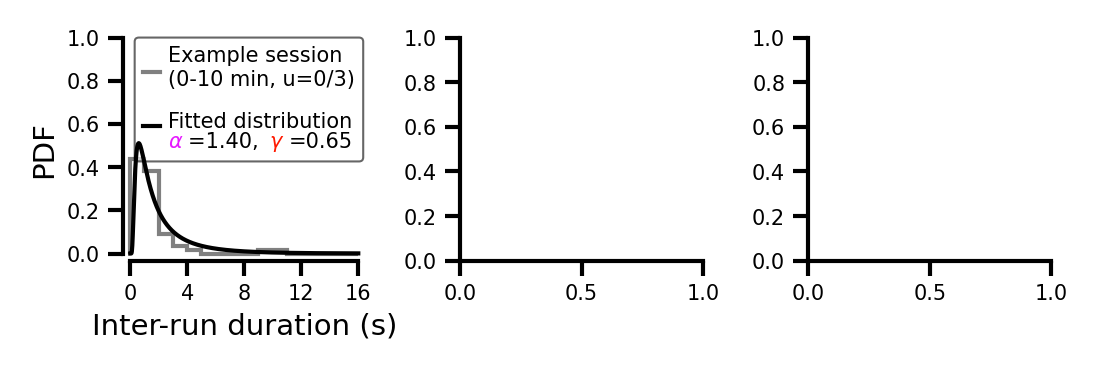

In [102]:
def Figure2_ABC_Left(ax=None, timebin=0, historybin=0, 
                           alphacolor=plt.get_cmap('cool_r')(0.1), gammacolor=plt.get_cmap('autumn')(0.1)):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    animal='RatM00'
    session='RatM00_2021_07_22_16_13_03'

    idletimes = prepare_data_idle_times(sequence, [animal], [session])
    idletimes = idletimes[animal][timebin][historybin]

    bins=np.linspace(0, 16, 17)
    ydata, xdata, _ = ax.hist(idletimes, bins=bins,
                    color='gray', zorder=4, lw=1,
                    density=True,
                    weights=np.ones_like(idletimes) / len(idletimes),
                    histtype="step")

    ax.plot([-10, -11], [-10, -11], c='gray', lw=1, label=f"Example session\n({timebin*10}-{(timebin+1)*10} min, u={historybin}/3)")
    
    x = np.linspace(0.01, 16, 1000)
    p, _ = wald_fit(idletimes)
    y = Wald_pdf(x, *p)
    ax.plot(x, y, zorder=10, lw=1, c='k')

    ax.set_xlim(0, 16)
    ax.set_xticks([0, 4, 8, 12, 16])
    ax.set_ylim(0, 1)
    ax.set_yticks([0, .2, .4, .6, .8, 1])
    ax.set_xlabel('Inter-run duration (s)')
    ax.set_ylabel('PDF')

    space_axes(ax)
    custom_combined_legend(ax, p[0], p[2], r"$\alpha$", r"$\gamma$", alphacolor, gammacolor, timebin=timebin, historybin=historybin)

fig, axs = plt.subplots(1, 3, figsize=(cm2inch(9), cm2inch(2.84)),)
Figure2_ABC_Left(axs[0], timebin=0, historybin=0)
# Figure2_ABC_Left(axs[1], timebin=5, historybin=0)
# Figure2_ABC_Left(axs[2], timebin=0, historybin=3)



# Figure 2D Explanation of the models (α0, αt, αu and γ0, γt, γu)


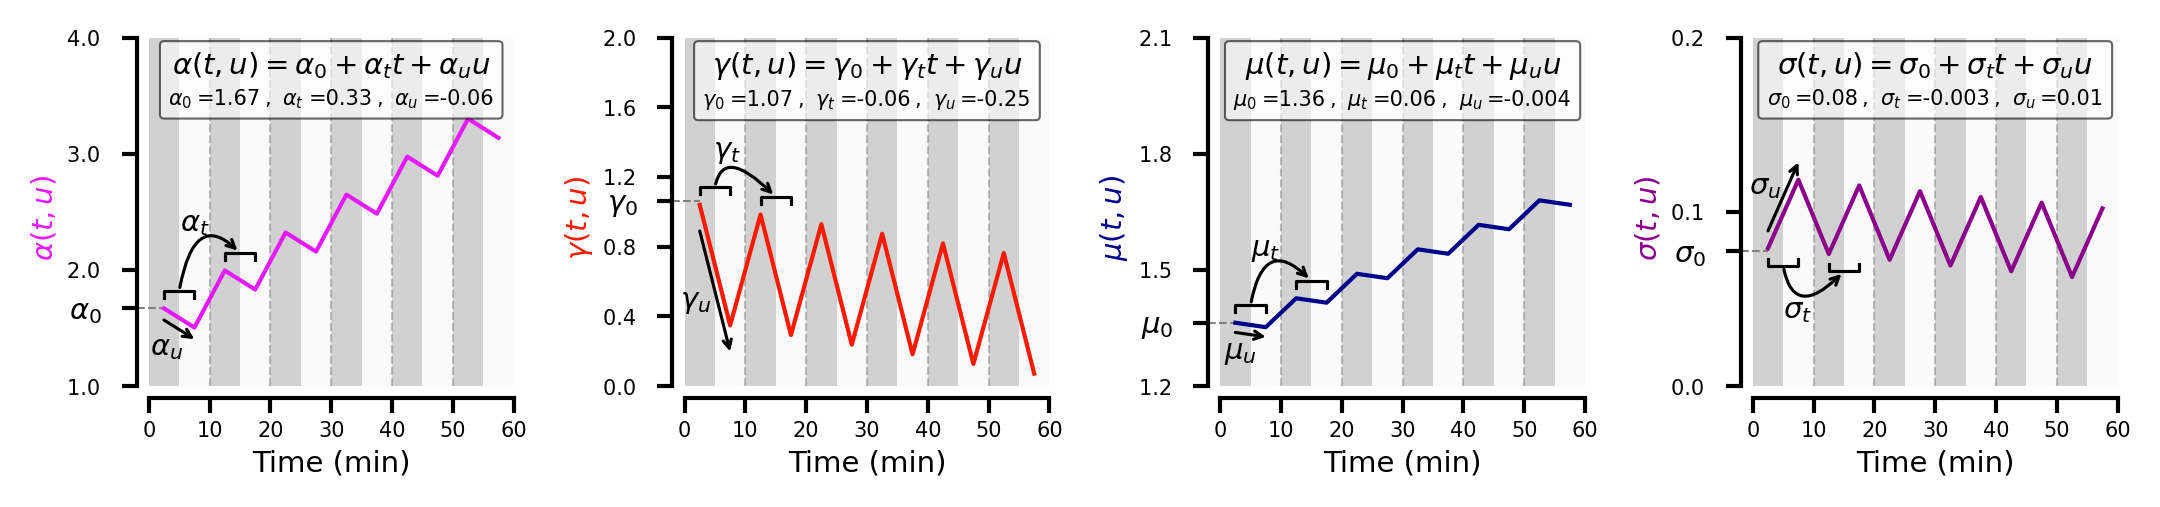

In [103]:

def Figure2D(var_to_plot, ax=None):
    if ax is None:
        _, ax = plt.subplots()

    rewardProbaBlock = [90, 10, 90, 10, 90, 10, 90, 10, 90, 10, 90, 10]
    blocks =  [[0, 300],  [300, 600],  [600, 900],  [900, 1200],
                [1200, 1500],  [1500, 1800],  [1800, 2100],  [2100, 2400],
                [2400, 2700],  [2700, 3000],  [3000, 3300],  [3300, 3600]]
    time = [(blocks[i][1] + blocks[i][0]) / 120 for i in range(12)]


    # load pickled and construct parameters
    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ex_mu, ex_mu_t, ex_mu_u, ex_sigma, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))

    N_bins, N_avg = 6, 4
    ALPHA = np.zeros((N_bins, N_avg))
    GAMMA = np.zeros((N_bins, N_avg))
    MU = np.zeros((N_bins, N_avg))
    SIGMA = np.zeros((N_bins, N_avg))

    for bin in range(N_bins):
        for avg in range(N_avg):
            ALPHA[bin, avg] = ex_alpha + bin*ex_alpha_t + avg*ex_alpha_u
            GAMMA[bin, avg] = ex_gamma + bin*ex_gamma_t + avg*ex_gamma_u
            MU[bin, avg] = ex_mu + bin*ex_mu_t + avg*ex_mu_u
            SIGMA[bin, avg] = ex_sigma + bin*ex_sigma_t + avg*ex_sigma_u

    a, g, m, s = [], [], [], []
    for i in range(6):
        a.append(.9*ALPHA[i][0]+0.1*ALPHA[i][1])
        a.append(.9*ALPHA[i][-1]+0.1*ALPHA[i][-2])
        g.append(.9*GAMMA[i][0]+0.1*GAMMA[i][1])
        g.append(.9*GAMMA[i][-1]+0.1*GAMMA[i][-2])
        m.append(.9*MU[i][0]+0.1*MU[i][1])
        m.append(.9*MU[i][-1]+0.1*MU[i][-2])
        s.append(.9*SIGMA[i][0]+0.1*SIGMA[i][1])
        s.append(.9*SIGMA[i][-1]+0.1*SIGMA[i][-2])

    # plot params for each variable
    config = {
        'alpha': {
            'color': plt.get_cmap('cool_r')(0.1),
            'var': a,
            'varname': r'$\alpha$',
            'names': [r'$\alpha_0$', r'$\alpha_t$', r'$\alpha_u$'],
            'equ': r'$\alpha(t, u) = \alpha_0 + \alpha_t t + \alpha_u u$',
            'num_vals': [ex_alpha, ex_alpha_t, ex_alpha_u],
            'ylims': (1, 4),
            'yticks': [1, 2, 3, 4],
            'xytexts': (1, -1),
            'xytexts_u': (0, -3),
            'angles': (-45, 80),
            'offset': 0.1,
        },
        'gamma': {
            'color': plt.get_cmap('autumn')(0.1),
            'var': g,
            'varname': r'$\gamma$',
            'names': [r'$\gamma_0$', r'$\gamma_t$', r'$\gamma_u$'],
            'equ': r'$\gamma(t, u) = \gamma_0 + \gamma_t t + \gamma_u u$',
            'num_vals': [ex_gamma, ex_gamma_t, ex_gamma_u],
            'ylims': (0, 2),
            'yticks': [0, 0.4, 0.8, 1.2, 1.6, 2],
            'xytexts': (-1, 1),
            'xytexts_u': (1, -1),
            'angles': (-45, 80),
            'offset': 0.15,
        },
        'mu': {
            'color': 'darkblue',
            'var': m,
            'varname': r'$\mu$',
            'names': [r'$\mu_0$', r'$\mu_t$', r'$\mu_u$'],
            'equ': r'$\mu(t, u) = \mu_0 + \mu_t t + \mu_u u$',
            'num_vals': [ex_mu, ex_mu_t, ex_mu_u],
            'ylims': (1.2, 2.1),
            'yticks': [1.2, 1.5, 1.8, 2.1],
            'xytexts': (1.5, -1),
            'xytexts_u': (0.5, -3),
            'angles': (-45, 80),
            'offset': 0.025,
        },
        'sigma': {
            'color': 'darkmagenta',
            'var': s,
            'varname': r'$\sigma$',
            'names': [r'$\sigma_0$', r'$\sigma_t$', r'$\sigma_u$'],
            'equ': r'$\sigma(t, u) = \sigma_0 + \sigma_t t + \sigma_u u$',
            'num_vals': [ex_sigma, ex_sigma_t, ex_sigma_u],
            'ylims': (0, 0.2),
            'yticks': [0, 0.1, 0.2],
            'xytexts': (-0.5, -1),
            'xytexts_u': (1, 2),
            'angles': (45, -80),
            'offset': -0.01,
        },
    }

    cfg = config[var_to_plot]
    var, num_vals, names = cfg['var'], cfg['num_vals'], cfg['names']

    # plot params and annotations (needs to be before annotations here)
    ax.set_xlabel("Time (min)")
    ax.set_xlim(0, 60)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_ylim(cfg['ylims'])
    yticks_all = sorted(cfg['yticks'] + [num_vals[0]])
    ax.set_yticks(yticks_all)
    ax.set_yticklabels([names[0] if t == num_vals[0] else str(t) for t in yticks_all])
    ax.plot([-2, 2.5], [num_vals[0]] * 2, '--', color='gray', lw=0.5, zorder=1)

    PARAMETERS_FS = 7
    for label in ax.get_yticklabels():
        if label.get_text().startswith("$"):
            label.set_fontsize(PARAMETERS_FS)
            # label.set_color(cfg['color'])

    def custom_formatter(x, pos):
        return names[0] + '  ' if abs(x - num_vals[0]) < 1e-6 else f'{x:<5.1f}'
    ax.yaxis.set_major_formatter(FuncFormatter(custom_formatter))
    ax.set_ylabel(cfg['varname'] + '$(t, u)$', color=cfg['color'])

    for i, (start, end) in enumerate(blocks):
        ax.axvspan(start / 60, end / 60, ymin=1 / 30, ymax=1, color='grey',alpha=rewardProbaBlock[i] / 250, lw=0)
    for x in range(10, 60, 10):
        ax.plot([x, x], cfg['ylims'], color='gray', lw=0.5, ls='--', zorder=0, alpha=0.5)

    # 0
    ax.plot(time, var, color=cfg['color'])

    # t
    space = 1.5
    h = (cfg['ylims'][1] - cfg['ylims'][0]) / 50 if var_to_plot != 'sigma' else - (cfg['ylims'][1] - cfg['ylims'][0]) / 50
    ax.plot([2.5, 2.5, 7.5, 7.5], [var[0] + space * h, var[0] + (space + 1) * h, var[0] + (space + 1) * h, var[0] + space * h], color='k', lw=0.75, zorder=5)
    ax.plot([12.5, 12.5, 17.5, 17.5], [var[2] + space * h, var[2] + (space + 1) * h, var[2] + (space + 1) * h, var[2] + space * h], color='k', lw=0.75, zorder=5)

    arrow = FancyArrowPatch(posA=(15, var[2] + (space + 1) * h), posB=(5, var[0] + (space + 1) * h),
                             arrowstyle='<-', connectionstyle=f"angle3,angleA={cfg['angles'][0]},angleB={cfg['angles'][1]}",
                             lw=0.75, color='k', shrinkA=0.85, shrinkB=0.85, mutation_scale=5, zorder=5)
    ax.add_patch(arrow)
    bend = arrow.get_path().vertices[1]
    ax.annotate(cfg['names'][1], xy=bend, xytext=cfg['xytexts_u'], textcoords='offset points',
                ha='center', va='center', fontsize=PARAMETERS_FS, zorder=5, 
                # color=cfg['color']
                )


    # u
    ax.annotate('', xy=(2.5, var[0] - cfg['offset']), xytext=(7.5, var[1] - cfg['offset']), fontsize=5,
                arrowprops=dict(arrowstyle='<-', lw=0.75, color='k', shrinkA=0, shrinkB=0), zorder=5)
    ax.annotate(cfg['names'][2], xy=(5, (var[0] + var[1]) / 2 - cfg['offset']),
                xytext=cfg['xytexts'], textcoords='offset points',
                # color=cfg['color'],
                ha='right', va='top' if num_vals[2] < 0 else 'bottom', fontsize=PARAMETERS_FS, zorder=5)

    # equation
    equation_legend(ax, cfg['equ'], names, num_vals, color='k', bbox=(0.5, .99))
    space_axes(ax)

fig, axs = plt.subplots(1, 4, figsize=(cm2inch(18), cm2inch(4)))
for ax, name in zip(axs, ['alpha', 'gamma', 'mu', 'sigma']):
    Figure2D(var_to_plot=name, ax=ax)


# Figure 2E Experimental data and model fit

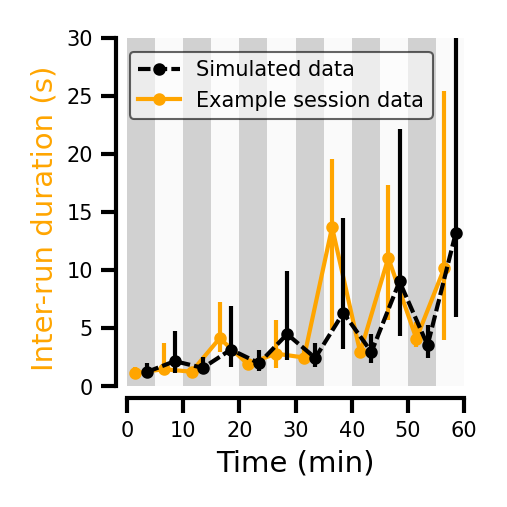

In [104]:
def Figure2E(root, ax=None, show_ylabel=False):
    if ax is None:
        ax = plt.gca()

    rewardProbaBlock = [90, 10, 90, 10, 90, 10, 90, 10, 90, 10, 90, 10]
    blocks =  [[0, 300],  [300, 600],  [600, 900],  [900, 1200],
                [1200, 1500],  [1500, 1800],  [1800, 2100],  [2100, 2400],
                [2400, 2700],  [2700, 3000],  [3000, 3300],  [3300, 3600]]
    
    for i in range(0, len(blocks)):
        ax.axvspan(blocks[i][0]/60, blocks[i][1]/60, ymin=1/30, ymax=1, color='grey', alpha=rewardProbaBlock[i]/250, lw=0)
    
    ax.set_xlabel("Time (min)")
    if show_ylabel:
        ax.set_ylabel("Inter-run duration (s)", color='orange')
    ax.set_xlim(0, 60)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_ylim(0, 30)
    # ax.set_yticks([0, 5, 10, 15])
    space_axes(ax)


    # experimental rat data
    animal='RatM00'
    session='RatM00_2021_07_22_16_13_03'

    _params = get_from_pickle(root, animal, session, name="params.p")
    blocks = _params['blocks']
    rewardProbaBlock = _params['rewardProbaBlock']
    example_runningTimeInLeftBin, example_runningTimeInRightBin = get_from_pickle(root, animal, session, name="timeinZone.p")
    data = [example_runningTimeInLeftBin[i]+example_runningTimeInRightBin[i] for i in range(0, 12)]

    data_medians = [np.median(data[i]) for i in range(12)]
    data_bot_percentiles = [np.percentile(data[i], 25) for i in range(12)]
    data_top_percentiles = [np.percentile(data[i], 75) for i in range(12)]
        
    ax.errorbar([-1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                data_medians,
                yerr=[[data_medians[i]-data_bot_percentiles[i] for i in range(12)], [data_top_percentiles[i]-data_medians[i] for i in range(12)]],
                marker='o', ms=2, color='orange', 
                zorder=4, alpha=1)


    # fit, generate samples from distribution with fit parameters, take median
    N_bins = 6
    N_avg = 4
    ex_alpha, ex_alpha_t, ex_alpha_u, ex_gamma, ex_gamma_t, ex_gamma_u = pickle.load(open("picklejar/example_session_fit_inter_run_duration.p", "rb"))
    ALPHA = np.zeros((N_bins, N_avg))
    GAMMA = np.zeros((N_bins, N_avg))

    for bin in range(N_bins):
        for avg in range(N_avg):
            ALPHA[bin, avg] = ex_alpha + bin*ex_alpha_t + avg*ex_alpha_u
            GAMMA[bin, avg] = ex_gamma + bin*ex_gamma_t + avg*ex_gamma_u

    a = []
    g = []
    for i in range(6):
        a.append(.9*ALPHA[i][0]+0.1*ALPHA[i][1])
        a.append(.9*ALPHA[i][-1]+0.1*ALPHA[i][-2])
        g.append(.9*GAMMA[i][0]+0.1*GAMMA[i][1])
        g.append(.9*GAMMA[i][-1]+0.1*GAMMA[i][-2])

    res = [generate_idle_time(a[i], g[i], 1000) for i in range(12)]
    medians = [np.median(res[i]) for i in range(12)]
    bot_percentiles = [np.percentile(res[i], 25) for i in range(12)]
    top_percentiles = [np.percentile(res[i], 75) for i in range(12)]

    ax.errorbar([1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                medians,
                yerr=[[medians[i]-bot_percentiles[i] for i in range(12)], [top_percentiles[i]-medians[i] for i in range(12)]],
                color='k', marker='o', ms=2, ls=(0, (3, 1)), zorder=5)
    
    ax.plot([-100, -101], [-100, -101], color='k', marker='o', ms=2, ls=(0, (3, 1)), label='Simulated data', zorder=5)
    ax.plot([-100, -101], [-100, -101], marker='o', ms=2, color='orange', zorder=4, alpha=1, label='Example session data')
   

    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique), loc='upper left', bbox_to_anchor=(0.01, 0.99), handlelength=2,
              frameon=True, fontsize=5, markerscale=1, edgecolor='k', 
              facecolor='w').get_frame().set_linewidth(.5)

fig, ax = plt.subplots(1, 1, figsize=(cm2inch(4), cm2inch(4)))

Figure2E(root, ax=ax, show_ylabel=True)

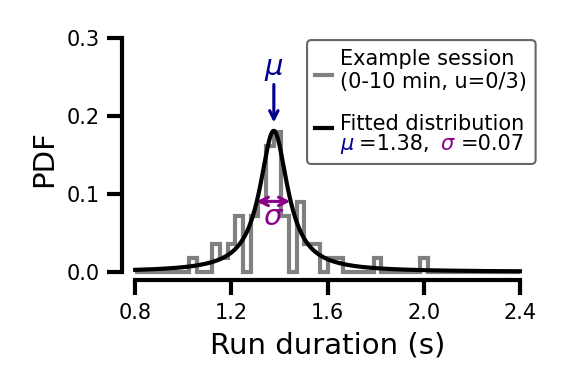

In [105]:

def FigureS6ABC(ax=None, timebin=0, historybin=0, plot_base=False):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    animal='RatM00'
    session='RatM00_2021_07_22_16_13_03'

    runtimes = prepare_data_running_times(sequence, [animal], [session])
    runtimes = runtimes[animal][timebin][historybin]



    bins=np.linspace(0.8, 2.4, 2*25+1)
    ydata, xdata, _ = ax.hist(runtimes, bins=bins,
                    color='gray', zorder=4, lw=1,
                    # density=True,
                    weights=np.ones_like(runtimes) / len(runtimes),
                    histtype="step")

    ax.plot([-10, -11], [-10, -11], c='gray', lw=1)

    x = np.linspace(0.8, 2.4, 1000)
    p = stats.cauchy.fit(runtimes)
    y = stats.cauchy.pdf(x, *p) /25
    _ = r'$\mu$' 
    __ = r'$\sigma$'
    

    if plot_base:
        _p = (1.3762326452135996, 0.07045912526547222)
        yy = stats.cauchy.pdf(x, *_p) /25
        ax.plot(x, yy, color='gray', zorder=9, ls='--', lw=1)
        ax.plot(x, y, color='k', zorder=10, ls='-', lw=1)

    if not plot_base:
        ax.plot(x, y, color='k', zorder=10, ls='-', lw=1)
        x_peak = x[np.argmax(y)]
        y_peak = y[np.argmax(y)]

        # mu arrow
        ax.annotate(text='', xy=(x_peak, y_peak), xytext=(x_peak, y_peak+.07), fontsize=5, zorder=5, 
                    arrowprops=dict(arrowstyle='->', lw=0.75, color='darkblue'))
        ax.annotate(text=r'$\mu$', xy=(x_peak, y_peak), xytext=(x_peak, y_peak+.08), ha='center', va='center',
                    xycoords='data', fontsize=7, zorder=5, color='darkblue')

        half_max = np.max(y)/2
        idx = np.argwhere(np.diff(np.sign(y - half_max))).flatten()
        ax.annotate(text='', xy=(x[idx[0]], half_max), xytext=(x[idx[-1]], half_max), fontsize=5, zorder=5,
                    arrowprops=dict(arrowstyle='<->', lw=0.75, shrinkA=0, shrinkB=0, color='darkmagenta'))
        ax.annotate(text=r'$\sigma$', xy=(x_peak, y_peak/2-.02), xytext=(x_peak, y_peak/2-.02), ha='center', va='center',
                    xycoords='data', fontsize=7, zorder=5, color='darkmagenta')


    ax.set_xlim(.8, 2.4)
    ax.set_xticks([.8, 1.2, 1.6, 2, 2.4])
    ax.set_ylim(0, .3)
    ax.set_yticks([0, .1, .2, .3])
    ax.set_xlabel('Run duration (s)')
    ax.set_ylabel('PDF')
    space_axes(ax)

    custom_combined_legend(ax, p[0], p[1], r"$\mu$", r"$\sigma$", 'darkblue', 'darkmagenta',
                           timebin=timebin, historybin=historybin, bbox=(0.45, .99))
    

fig, axs = plt.subplots(1, 1, figsize=(cm2inch(4.5), cm2inch(3)),)
FigureS6ABC(axs, timebin=0, historybin=0)
# FigureS6ABC(axs[1], timebin=5, historybin=0, plot_base=True)
# FigureS6ABC(axs[2], timebin=0, historybin=3, plot_base=True)

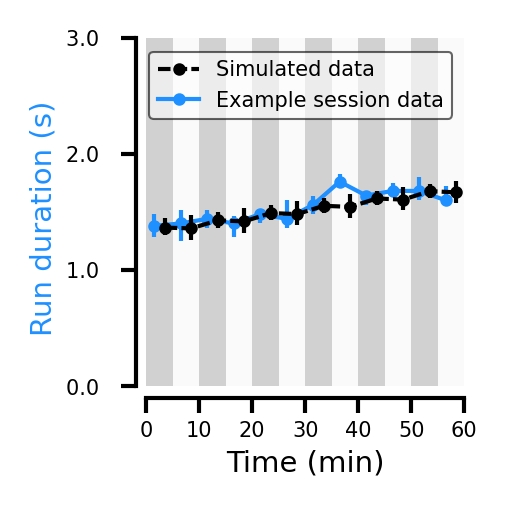

In [106]:

def FigureS6E(root, ax=None, show_ylabel=False):
    if ax is None:
        ax = plt.gca()

    rewardProbaBlock = [90, 10, 90, 10, 90, 10, 90, 10, 90, 10, 90, 10]
    blocks =  [[0, 300],  [300, 600],  [600, 900],  [900, 1200],
                [1200, 1500],  [1500, 1800],  [1800, 2100],  [2100, 2400],
                [2400, 2700],  [2700, 3000],  [3000, 3300],  [3300, 3600]]
    
    for i in range(0, len(blocks)):
        ax.axvspan(blocks[i][0]/60, blocks[i][1]/60, ymin=1/30, ymax=1, color='grey', alpha=rewardProbaBlock[i]/250, lw=0)
    
    ax.set_xlabel("Time (min)")
    if show_ylabel:
        ax.set_ylabel("Run duration (s)", color='dodgerblue')
    ax.set_xlim(0, 60)
    ax.set_xticks([0, 10, 20, 30, 40, 50, 60])
    ax.set_ylim(0, 3)
    ax.set_yticks([0, 1, 2, 3])
    ax.yaxis.set_major_formatter('{x:<5.1f}')
    space_axes(ax)


    # experimental rat data
    animal='RatM00'
    session='RatM00_2021_07_22_16_13_03'

    _params = get_from_pickle(root, animal, session, name="params.p")
    blocks = _params['blocks']
    rewardProbaBlock = _params['rewardProbaBlock']
    example_runningTimeInLeftBin, example_runningTimeInRightBin = get_from_pickle(root, animal, session, name="timeRun.p")
    data = [example_runningTimeInLeftBin[i]+example_runningTimeInRightBin[i] for i in range(0, 12)]

    data_medians = [np.median(data[i]) for i in range(12)]
    data_bot_percentiles = [np.percentile(data[i], 25) for i in range(12)]
    data_top_percentiles = [np.percentile(data[i], 75) for i in range(12)]
        
    ax.errorbar([-1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                data_medians,
                yerr=[[data_medians[i]-data_bot_percentiles[i] for i in range(12)], [data_top_percentiles[i]-data_medians[i] for i in range(12)]],
                marker='o', ms=2, color='dodgerblue', 
                zorder=4, alpha=1, label='Example session data')


    # fit, generate samples from distribution with fit parameters, take median
    N_bins = 6
    N_avg = 4
    ex_mu, ex_mu_t, ex_mu_u, ex_sigma, ex_sigma_t, ex_sigma_u = pickle.load(open("picklejar/example_session_fit_run_duration.p", "rb"))
    MU = np.zeros((N_bins, N_avg))
    SIGMA = np.zeros((N_bins, N_avg))

    for bin in range(N_bins):
        for avg in range(N_avg):
            MU[bin, avg] = ex_mu + bin*ex_mu_t + avg*ex_mu_u
            SIGMA[bin, avg] = ex_sigma + bin*ex_sigma_t + avg*ex_sigma_u

    m = []
    s = []
    for i in range(6):
        m.append((.9*MU[i][0] + 0.1*MU[i][1]))
        m.append((.9*MU[i][-1] + 0.1*MU[i][-2]))
        s.append((.9*SIGMA[i][0] + 0.1*SIGMA[i][1]))
        s.append((.9*SIGMA[i][-1] + 0.1*SIGMA[i][-2]))


    res = [generate_running_time(m[i], s[i], 1000) for i in range(12)]
    medians = [np.median(res[i]) for i in range(12)]
    bot_percentiles = [np.nanpercentile(res[i], 25) for i in range(12)]
    top_percentiles = [np.nanpercentile(res[i], 75) for i in range(12)]

    ax.errorbar([1+(blocks[i][1] + blocks[i][0])/120 for i in range(0, len(blocks))],
                medians,
                yerr=[[medians[i]-bot_percentiles[i] for i in range(12)], [top_percentiles[i]-medians[i] for i in range(12)]],
                color='k', marker='o', ms=2, ls=(0, (3, 1)), zorder=5)

    ax.plot([-100, -101], [-100, -101], color='k', marker='o', ms=2, ls=(0, (3, 1)), label='Simulated data', zorder=5)
    ax.plot([-100, -101], [-100, -101], marker='o', ms=2, color='dodgerblue', zorder=4, alpha=1, label='Example session data')
   
    handles, labels = ax.get_legend_handles_labels()
    unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
    ax.legend(*zip(*unique), loc='upper left', bbox_to_anchor=(0.01, 0.99), frameon=True, fontsize=5, markerscale=1, edgecolor='k', facecolor='w').get_frame().set_linewidth(.5)

fig, ax = plt.subplots(1, 1, figsize=(cm2inch(4), cm2inch(4)))
FigureS6E(root=root, ax=ax, show_ylabel=True)


# Figure 2: Model-based quantification of intra-session dynamics of inter-run duration.

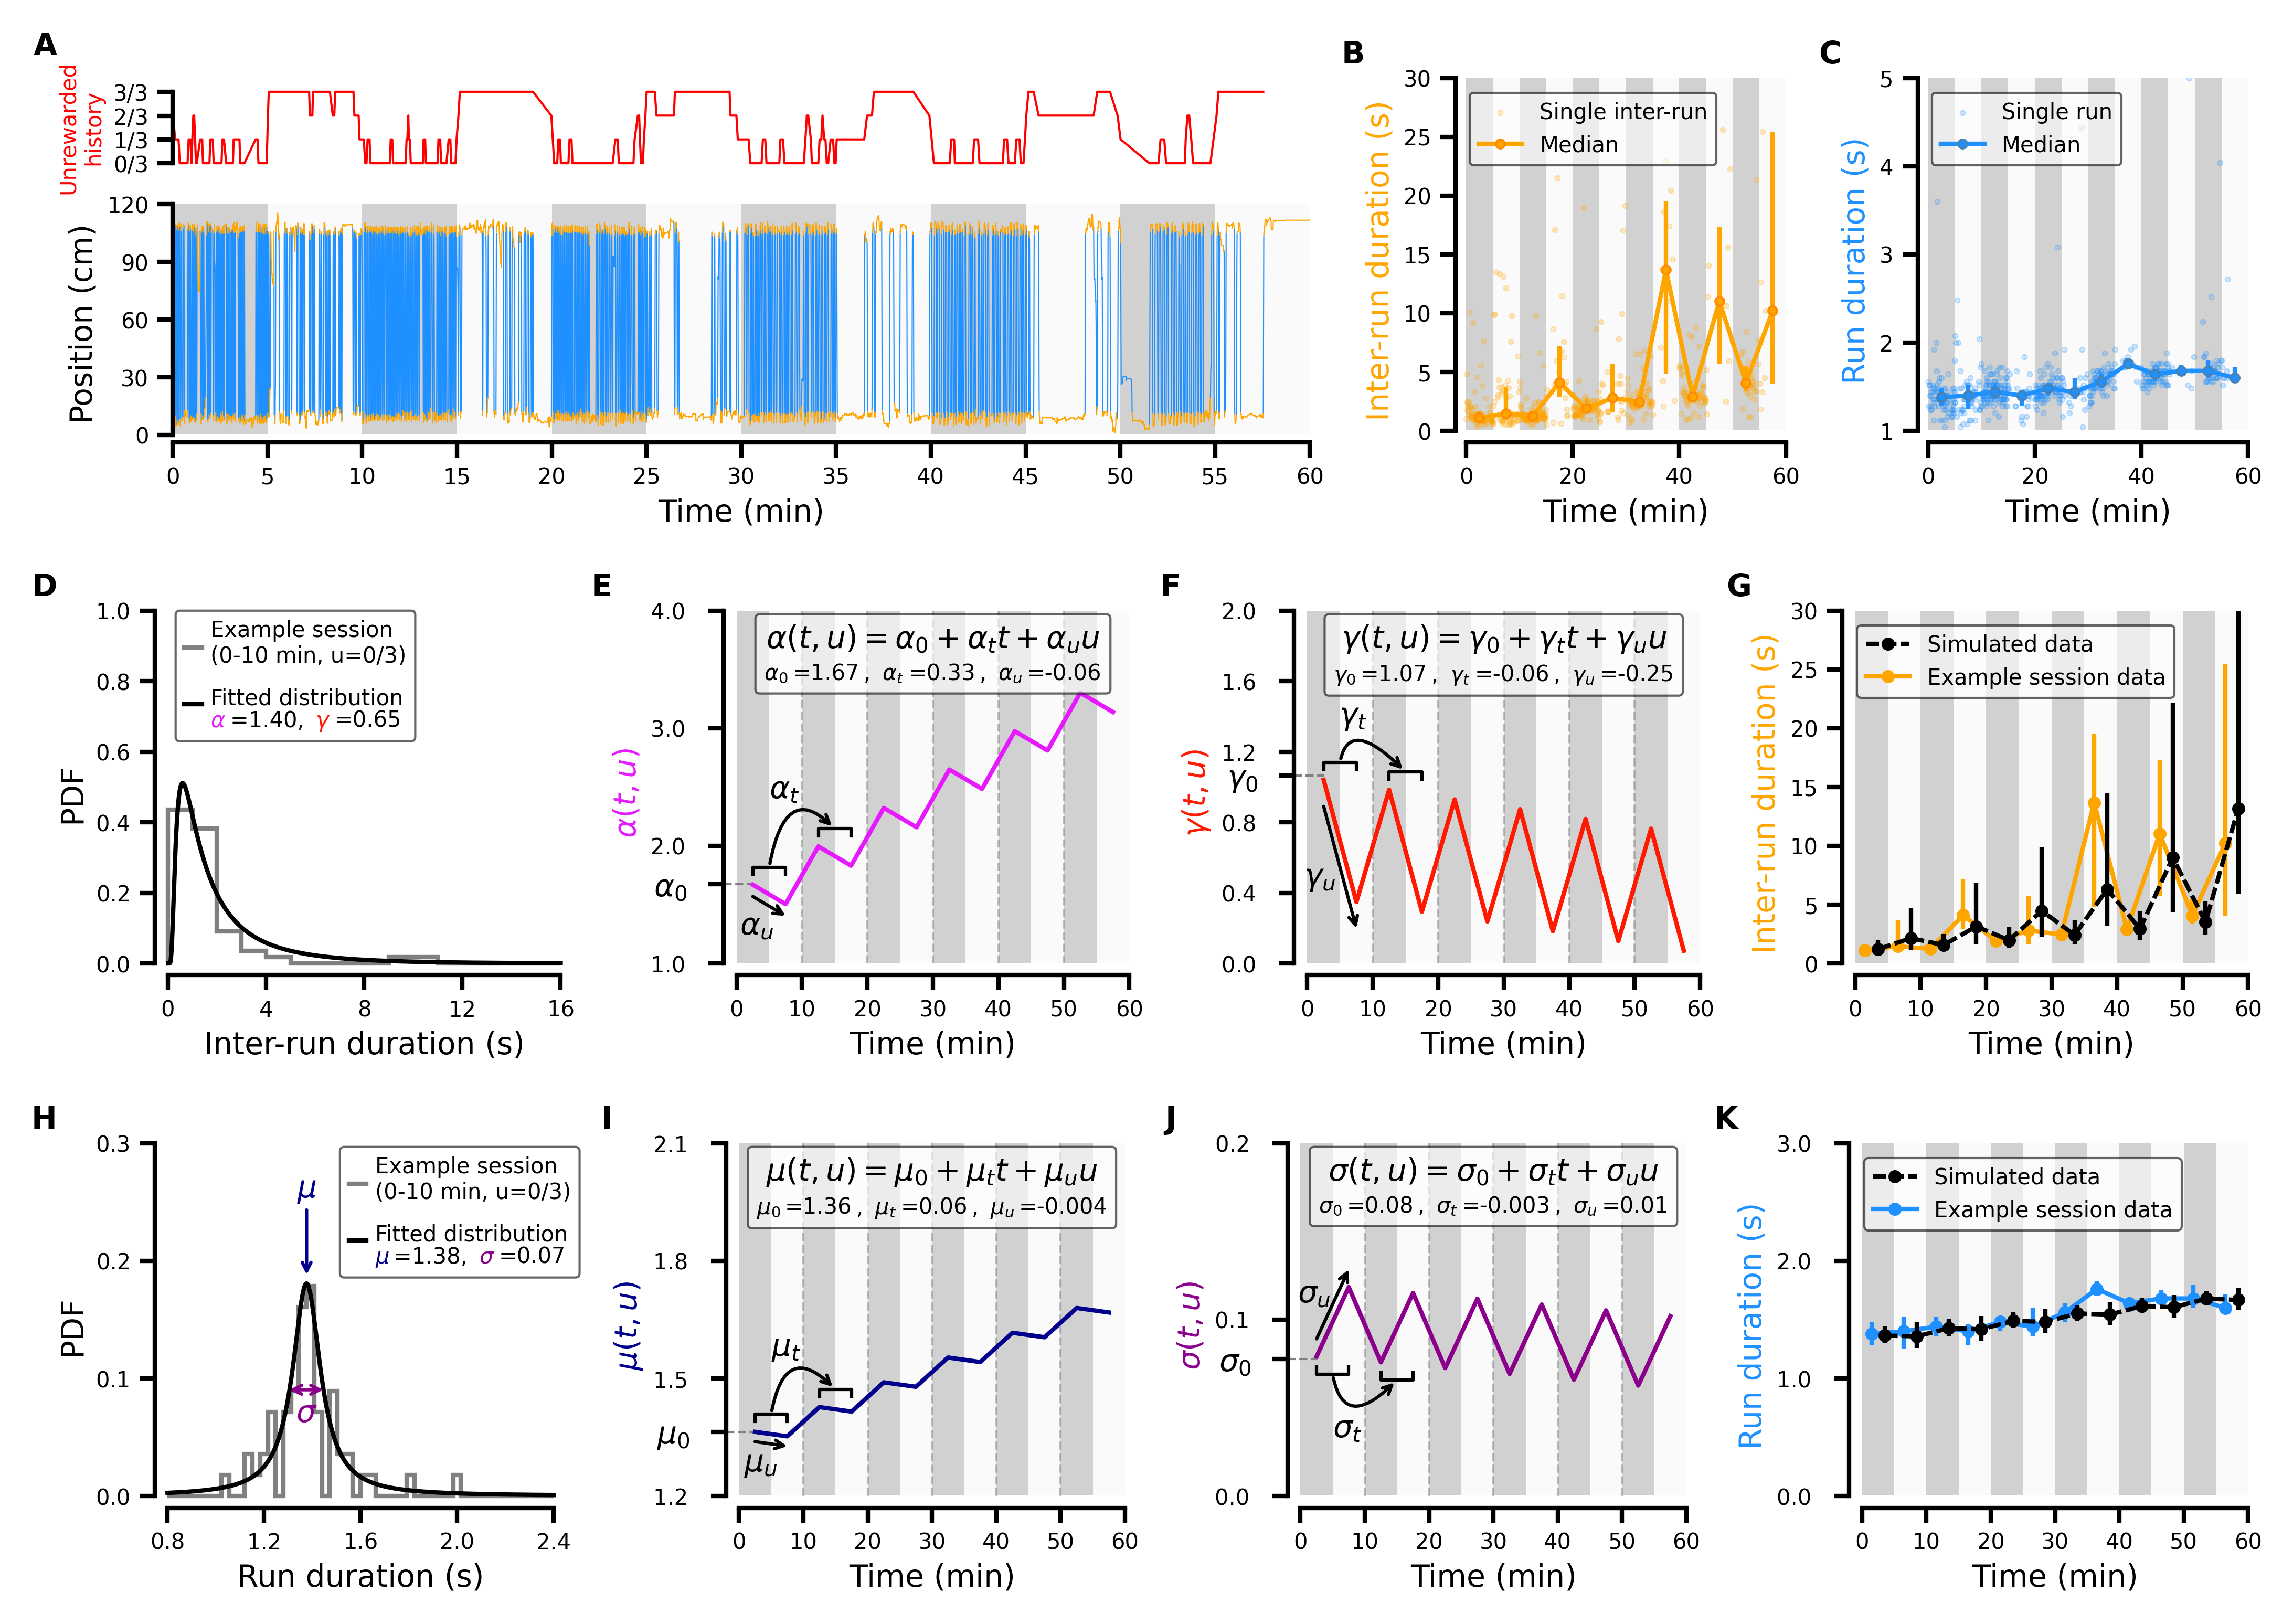

In [107]:
fig = plt.figure(figsize=(cm2inch(18), cm2inch(12.5)),
                #  constrained_layout=True, 
                 facecolor='w', dpi=600)


gs = fig.add_gridspec(5, 1, height_ratios=[1, .1, 1, .1, 1])

task = gs[0].subgridspec(2, 3, height_ratios=[1.1, 4], width_ratios=[5, 1.5, 1.5])
raw_track_proba = plt.subplot(task[0, 0])
raw_track_track = plt.subplot(task[1, 0], sharex=raw_track_proba)
inter_runs = plt.subplot(task[:, 1])
runs = plt.subplot(task[:, 2])

model_IR = gs[2].subgridspec(1, 4, width_ratios=[1, 1, 1, 1])
IR_fit_base = plt.subplot(model_IR[0])
IR_explanation_alpha = plt.subplot(model_IR[1])
IR_explanation_gamma = plt.subplot(model_IR[2])
IR_model_0tu = plt.subplot(model_IR[3])

model_R = gs[4].subgridspec(1, 4, width_ratios=[1, 1, 1, 1])
R_fit_base = plt.subplot(model_R[0])
R_explanation_mu = plt.subplot(model_R[1])
R_explanation_sigma = plt.subplot(model_R[2])
R_model_0tu = plt.subplot(model_R[3])


Figure1B(ax=raw_track_track, root=root)
Figure1Bbis(ax=raw_track_proba, root=root)
Figure1D(ax=inter_runs, root=root)
Figure1E(ax=runs, root=root)

Figure2_ABC_Left(IR_fit_base, timebin=0, historybin=0)
Figure2D(var_to_plot='alpha', ax=IR_explanation_alpha)
Figure2D(var_to_plot='gamma', ax=IR_explanation_gamma)
Figure2E(root, ax=IR_model_0tu, show_ylabel=True)

FigureS6ABC(R_fit_base, timebin=0, historybin=0)
Figure2D(var_to_plot='mu', ax=R_explanation_mu)
Figure2D(var_to_plot='sigma', ax=R_explanation_sigma)
FigureS6E(root=root, ax=R_model_0tu, show_ylabel=True)


# shift and enlarge proba ax 
fig.canvas.draw()
proba_bounds = raw_track_proba.get_position().bounds
track_bounds = raw_track_track.get_position().bounds
new_y = proba_bounds[1] - 0.015
new_height = proba_bounds[3] * 1.2
raw_track_proba.set_position([proba_bounds[0], new_y, proba_bounds[2], new_height])

axs = [raw_track_proba, inter_runs, runs,
       IR_fit_base, IR_explanation_alpha, IR_explanation_gamma, IR_model_0tu,
       R_fit_base, R_explanation_mu, R_explanation_sigma, R_model_0tu]
letters = ["A", "B", "C",
           "D", "E", "F", "G",
           "H", "I", "J", "K"]

add_all_letters(axs, letters)

plt.savefig("./Figures_paper/Figure_2.pdf", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_2.svg", facecolor='w', 
        edgecolor='none', bbox_inches='tight', format="svg", dpi=600)